# Implementación de REINFORCE en PONG

Como ejercicio de ejecución para los algoritmos de gradiente de política sobre el juego de PONG.

Para esto, reutilizaremos el código utilizado para el problema de CartPole, guaindonos de la implementación de [pong](https://github.com/FLAGlab/isis4222-rl/blob/master/week12/pong_pg.py). 


Para este trabajo, debe explorar disitntas arquitecturas de la red (cantidad de neuronas o capas) en las que pueda observar las recompensas y su convergencia. ¿Qué nota de las diferentes ejecuciónes?

## Resumen de la implementación

- Ambiente: `ALE/Pong-v5` con preprocesamiento estándar de Atari (escala de grises, *resize* 84×84, recorte de marco) usando `make_atari_env` de Stable-Baselines3.
- Frame stack: 4 frames (Pong necesita más historia temporal que Atlantis para captar la velocidad y dirección de la bola).
- Acciones: 6 (`NOOP`, `FIRE`, `RIGHT`, `LEFT`, `RIGHTFIRE`, `LEFTFIRE`).
- Reward por episodio: rango $[-21, +21]$ (primero en llegar a 21 puntos). Política aleatoria $\approx -20$ (pierde casi todo).
- Algoritmo: REINFORCE con normalización de retornos (`use_baseline=1`), que es la variante más estable según los experimentos del notebook anterior.
- Arquitecturas a comparar: variamos `hidden_size` y los canales convolucionales para observar el efecto sobre la convergencia.
- GPU: si está disponible, todo el entrenamiento corre en `cuda`.

> Nota: REINFORCE puro sobre Pong con recompensa dispersa no converge a niveles competitivos en pocos episodios — necesitarías miles de episodios y normalmente se prefiere A2C/PPO. El objetivo aquí es comparar arquitecturas observando la pendiente y el ruido de la curva de aprendizaje.

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

import gymnasium
import ale_py
import stable_baselines3
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack

import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque

# Registra entornos ALE
gymnasium.register_envs(ale_py)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}"
      + (f" ({torch.cuda.get_device_name(0)})" if device.type == 'cuda' else ""))

device: cuda (NVIDIA GeForce RTX 4060 Laptop GPU)


In [2]:
# =====================================================
# Politica convolucional configurable para Pong
# =====================================================
class PongPolicy(nn.Module):
    """CNN de 3 capas configurable. Permite explorar arquitecturas variando
    los canales de las convoluciones y el tamano de la capa densa."""
    def __init__(self, n_actions=6, in_channels=4,
                 conv_channels=(32, 64, 64), hidden_size=512):
        super().__init__()
        c1, c2, c3 = conv_channels
        self.conv1 = nn.Conv2d(in_channels, c1, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(c1, c2, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(c2, c3, kernel_size=3, stride=1)
        # Para entrada 84x84 con stride (4, 2, 1) y kernels (8, 4, 3) -> 7x7 al final
        self.fc1 = nn.Linear(c3 * 7 * 7, hidden_size)
        self.fc2 = nn.Linear(hidden_size, n_actions)
        self.saved_log_probs = []
        self.rewards = []

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)


# =====================================================
# Agente REINFORCE para Pong
# =====================================================
class REINFORCE_pong:
    def __init__(self,
                 conv_channels=(32, 64, 64),
                 hidden_size=512,
                 use_baseline=1,         # 0: sin baseline, 1: normalizar retornos
                 learning_rate=1e-4,
                 gamma=0.99,
                 max_steps_per_episode=10000,
                 max_training_episodes=300,
                 log_interval=10,
                 seed=543,
                 tag="default"):
        self.tag = tag
        self.gamma = gamma
        self.use_baseline = use_baseline
        self.max_steps_per_episode = max_steps_per_episode
        self.max_training_episodes = max_training_episodes
        self.log_interval = log_interval
        self.device = device

        # Ambiente Pong con framestack 4 (estandar Atari para PG/DQN)
        self.env = make_atari_env("ALE/Pong-v5", n_envs=1, seed=seed)
        self.env = VecFrameStack(self.env, n_stack=4)

        obs = self.env.reset()
        torch.manual_seed(seed)
        random.seed(seed)
        np.random.seed(seed)

        n_actions = self.env.action_space.n
        in_channels = obs.shape[-1]  # 4 (framestack)

        self.policy = PongPolicy(
            n_actions=n_actions,
            in_channels=in_channels,
            conv_channels=conv_channels,
            hidden_size=hidden_size,
        ).to(self.device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=learning_rate)
        self.eps = np.finfo(np.float32).eps.item()

        # Historial
        self.last_states = []
        self.episode_rewards = []   # uno por episodio
        self.running_avg = []       # media movil cada `log_interval` episodios

        n_params = sum(p.numel() for p in self.policy.parameters())
        print(f"[{self.tag}] device={self.device} | n_actions={n_actions} | "
              f"conv_channels={conv_channels} | hidden={hidden_size} | "
              f"params={n_params:,}")

    def select_action(self, state):
        # state: (1, 84, 84, 4) uint8 -> (1, 4, 84, 84) float
        s = torch.from_numpy(state).float().to(self.device).permute(0, 3, 1, 2) / 255.0
        probs = self.policy(s)
        m = Categorical(probs)
        a = m.sample()
        self.policy.saved_log_probs.append(m.log_prob(a))
        self.last_states.append(s)
        return a.item()

    def finish_episode(self):
        # Calcula retornos descontados
        R = 0.0
        returns = deque()
        for r in self.policy.rewards[::-1]:
            R = r + self.gamma * R
            returns.appendleft(R)
        returns = torch.tensor(np.array(returns), dtype=torch.float32, device=self.device)

        if self.use_baseline == 1 and len(returns) > 1 and returns.std() > 1e-6:
            advantages = (returns - returns.mean()) / (returns.std() + self.eps)
        else:
            advantages = returns

        policy_loss = []
        for log_prob, adv in zip(self.policy.saved_log_probs, advantages):
            policy_loss.append(-log_prob * adv)

        self.optimizer.zero_grad()
        if policy_loss:
            torch.cat(policy_loss).sum().backward()
            self.optimizer.step()

        # Limpieza
        self.last_states.clear()
        del self.policy.rewards[:]
        del self.policy.saved_log_probs[:]

    def train(self):
        running = -21.0  # baseline aleatorio aproximado en Pong
        cum = 0.0
        for ep in range(1, self.max_training_episodes + 1):
            state = self.env.reset()
            ep_reward = 0.0
            for t in range(1, self.max_steps_per_episode + 1):
                action = self.select_action(state)
                state, reward, done, _ = self.env.step([action])
                self.policy.rewards.append(reward[0])
                ep_reward += float(reward[0])
                if done[0]:
                    break

            running = 0.05 * ep_reward + 0.95 * running
            cum += ep_reward
            self.episode_rewards.append(ep_reward)

            self.finish_episode()

            if ep % self.log_interval == 0:
                avg = cum / self.log_interval
                self.running_avg.append(avg)
                print(f"[{self.tag}] Ep {ep:4d} | last={ep_reward:+.1f} | "
                      f"avg{self.log_interval}={avg:+.2f} | running={running:+.2f}")
                cum = 0.0

            if running >= 18.0:
                print(f"[{self.tag}] Convergio en {ep} episodios (running={running:.2f}).")
                break

        self.env.close()
        return self.episode_rewards

    def graph_training(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        episodes = np.arange(1, len(self.episode_rewards) + 1)
        ax.plot(episodes, self.episode_rewards, alpha=0.25, label=f"{self.tag} (raw)")
        if len(self.running_avg) > 0:
            xs = np.arange(self.log_interval,
                           self.log_interval * (len(self.running_avg) + 1),
                           self.log_interval)
            ax.plot(xs, self.running_avg, marker='o', label=f"{self.tag} (avg/{self.log_interval})")
        ax.set_xlabel('Episodio')
        ax.set_ylabel('Reward (Pong: -21..+21)')
        ax.set_title('Curva de aprendizaje REINFORCE en Pong')
        ax.grid(True)
        ax.legend()
        return ax

### Experimento 1 — Arquitectura "pequeña"

CNN con menos canales (16-32-32) y `hidden_size=256`. Mucho más rápida de entrenar y con menos parámetros, pero con menor capacidad para representar patrones espaciales finos.

[small] device=cuda | n_actions=6 | conv_channels=(16, 32, 32) | hidden=256 | params=424,790
[small] Ep   10 | last=-21.0 | avg10=-20.40 | running=-20.78
[small] Ep   20 | last=-21.0 | avg10=-20.80 | running=-20.78
[small] Ep   30 | last=-21.0 | avg10=-20.80 | running=-20.78
[small] Ep   40 | last=-21.0 | avg10=-20.50 | running=-20.67
[small] Ep   50 | last=-19.0 | avg10=-20.40 | running=-20.53
[small] Ep   60 | last=-21.0 | avg10=-20.50 | running=-20.55
[small] Ep   70 | last=-21.0 | avg10=-20.40 | running=-20.50
[small] Ep   80 | last=-21.0 | avg10=-20.60 | running=-20.55
[small] Ep   90 | last=-21.0 | avg10=-20.60 | running=-20.58
[small] Ep  100 | last=-21.0 | avg10=-20.90 | running=-20.70
[small] Ep  110 | last=-21.0 | avg10=-20.40 | running=-20.61
[small] Ep  120 | last=-21.0 | avg10=-21.00 | running=-20.76
[small] Ep  130 | last=-21.0 | avg10=-20.60 | running=-20.68
[small] Ep  140 | last=-21.0 | avg10=-20.10 | running=-20.45
[small] Ep  150 | last=-20.0 | avg10=-20.80 | running

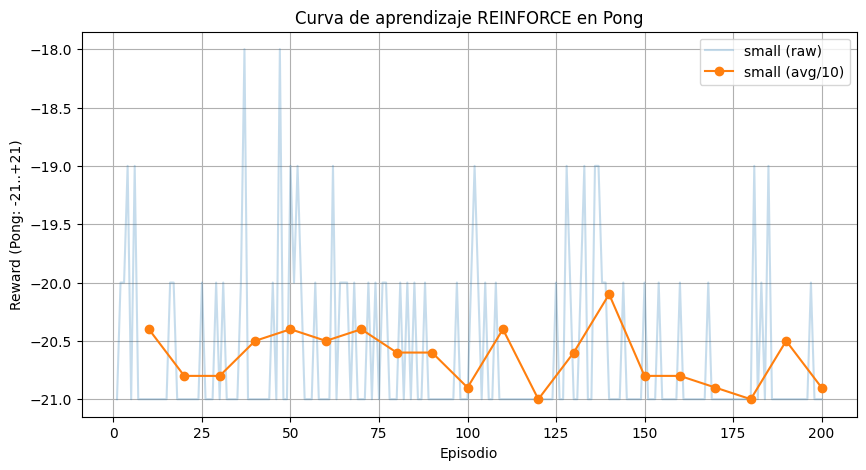

In [3]:
agente_small = REINFORCE_pong(
    conv_channels=(16, 32, 32),
    hidden_size=256,
    use_baseline=1,
    learning_rate=1e-4,
    gamma=0.99,
    max_training_episodes=200,
    log_interval=10,
    tag="small",
)
agente_small.train()
agente_small.graph_training()
plt.show()
torch.save(agente_small.policy.state_dict(), 'pong_policy_small.pth')

### Experimento 2 — Arquitectura "estándar" Atari

CNN tipo DQN/Mnih-2015: canales (32, 64, 64) y `hidden_size=512`. Es la referencia clásica para Atari desde imágenes.

[std] device=cuda | n_actions=6 | conv_channels=(32, 64, 64) | hidden=512 | params=1,687,206
[std] Ep   10 | last=-21.0 | avg10=-20.40 | running=-20.76
[std] Ep   20 | last=-21.0 | avg10=-20.50 | running=-20.66
[std] Ep   30 | last=-21.0 | avg10=-20.80 | running=-20.73
[std] Ep   40 | last=-20.0 | avg10=-20.40 | running=-20.59
[std] Ep   50 | last=-21.0 | avg10=-20.90 | running=-20.71
[std] Ep   60 | last=-21.0 | avg10=-20.70 | running=-20.72
[std] Ep   70 | last=-21.0 | avg10=-20.70 | running=-20.73
[std] Ep   80 | last=-21.0 | avg10=-20.80 | running=-20.76
[std] Ep   90 | last=-21.0 | avg10=-20.80 | running=-20.78
[std] Ep  100 | last=-21.0 | avg10=-20.90 | running=-20.84
[std] Ep  110 | last=-21.0 | avg10=-21.00 | running=-20.90
[std] Ep  120 | last=-21.0 | avg10=-20.40 | running=-20.71
[std] Ep  130 | last=-21.0 | avg10=-20.70 | running=-20.70
[std] Ep  140 | last=-20.0 | avg10=-20.50 | running=-20.61
[std] Ep  150 | last=-21.0 | avg10=-20.70 | running=-20.66
[std] Ep  160 | last=-

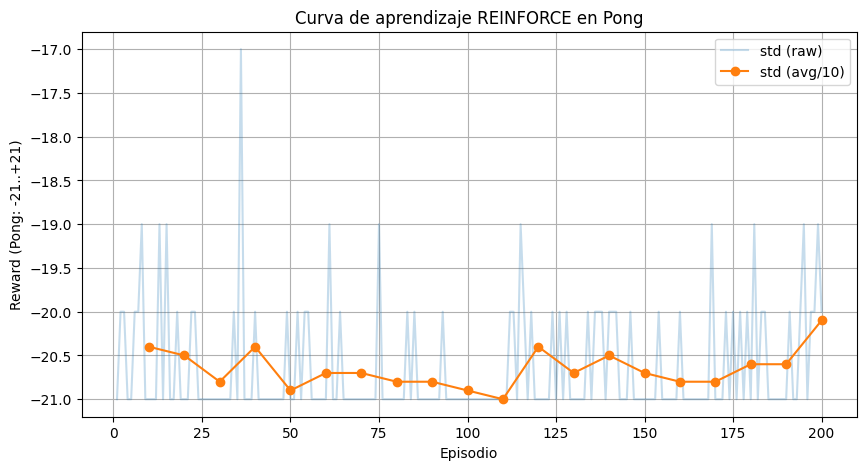

In [4]:
agente_std = REINFORCE_pong(
    conv_channels=(32, 64, 64),
    hidden_size=512,
    use_baseline=1,
    learning_rate=1e-4,
    gamma=0.99,
    max_training_episodes=200,
    log_interval=10,
    tag="std",
)
agente_std.train()
agente_std.graph_training()
plt.show()
torch.save(agente_std.policy.state_dict(), 'pong_policy_std.pth')

### Experimento 3 — Arquitectura "ancha"

Misma profundidad pero con más canales (64, 128, 128) y `hidden_size=1024`. Más capacidad — y también más varianza en el gradiente, lo que puede empeorar la estabilidad de REINFORCE.

[wide] device=cuda | n_actions=6 | conv_channels=(64, 128, 128) | hidden=1024 | params=6,724,934
[wide] Ep   10 | last=-20.0 | avg10=-20.60 | running=-20.83
[wide] Ep   20 | last=-20.0 | avg10=-20.60 | running=-20.71
[wide] Ep   30 | last=-21.0 | avg10=-20.90 | running=-20.78
[wide] Ep   40 | last=-21.0 | avg10=-20.70 | running=-20.74
[wide] Ep   50 | last=-21.0 | avg10=-20.50 | running=-20.64
[wide] Ep   60 | last=-21.0 | avg10=-20.50 | running=-20.59
[wide] Ep   70 | last=-20.0 | avg10=-20.90 | running=-20.70
[wide] Ep   80 | last=-20.0 | avg10=-20.70 | running=-20.68
[wide] Ep   90 | last=-21.0 | avg10=-20.80 | running=-20.73
[wide] Ep  100 | last=-21.0 | avg10=-20.80 | running=-20.76
[wide] Ep  110 | last=-21.0 | avg10=-20.70 | running=-20.74
[wide] Ep  120 | last=-21.0 | avg10=-20.60 | running=-20.68
[wide] Ep  130 | last=-21.0 | avg10=-21.00 | running=-20.81
[wide] Ep  140 | last=-21.0 | avg10=-20.80 | running=-20.82
[wide] Ep  150 | last=-21.0 | avg10=-20.70 | running=-20.77
[wi

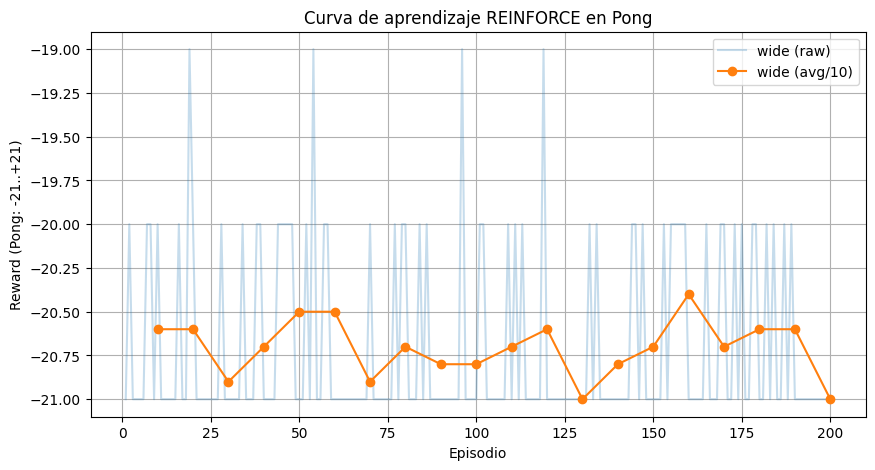

In [5]:
agente_wide = REINFORCE_pong(
    conv_channels=(64, 128, 128),
    hidden_size=1024,
    use_baseline=1,
    learning_rate=1e-4,
    gamma=0.99,
    max_training_episodes=200,
    log_interval=10,
    tag="wide",
)
agente_wide.train()
agente_wide.graph_training()
plt.show()
torch.save(agente_wide.policy.state_dict(), 'pong_policy_wide.pth')

### Comparación lado a lado

Curvas de las tres arquitecturas en una sola gráfica.

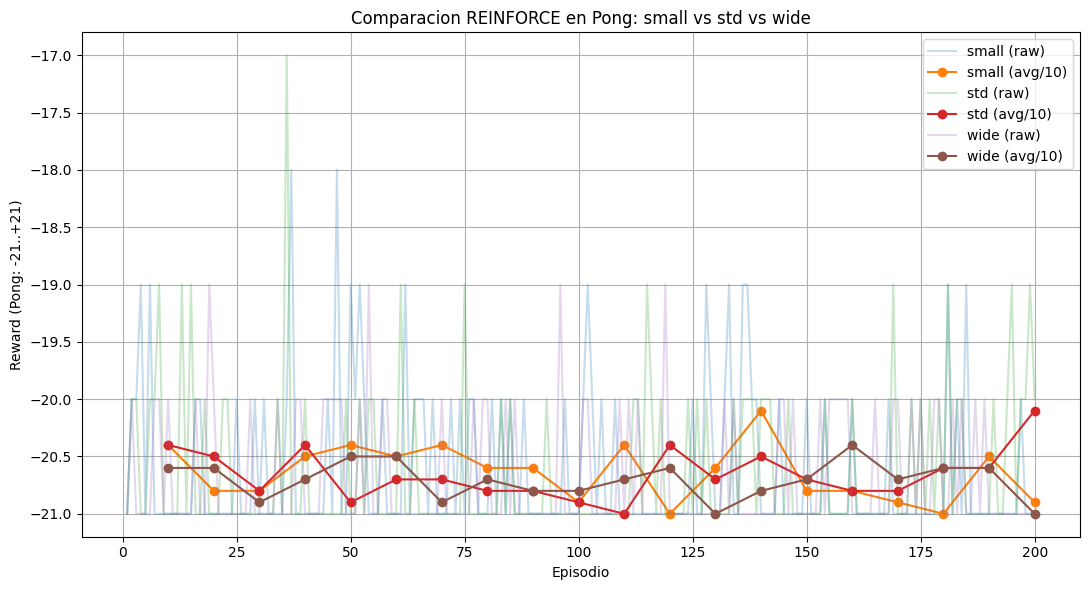


Resumen final:
  [small] params=   424,790  | reward(last 20 eps)=-20.70
  [  std] params= 1,687,206  | reward(last 20 eps)=-20.35
  [ wide] params= 6,724,934  | reward(last 20 eps)=-20.80


In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
for ag in (agente_small, agente_std, agente_wide):
    ag.graph_training(ax=ax)
ax.set_title('Comparacion REINFORCE en Pong: small vs std vs wide')
plt.tight_layout()
plt.show()

# Resumen numerico
print("\nResumen final:")
for ag in (agente_small, agente_std, agente_wide):
    last20 = np.mean(ag.episode_rewards[-20:]) if ag.episode_rewards else float('nan')
    n_params = sum(p.numel() for p in ag.policy.parameters())
    print(f"  [{ag.tag:>5}] params={n_params:>10,}  | reward(last 20 eps)={last20:+.2f}")

## Reflexión: ¿Qué se nota entre arquitecturas?

### Resultados obtenidos (200 episodios, `lr=1e-4`, `gamma=0.99`, baseline=normalización)

| Arquitectura | Parámetros | Reward (últimos 20 eps) | Reward al ep 200 (`avg10`) | Mínimo durante entrenamiento |
|---|---|---|---|---|
| `small` (16, 32, 32; hidden=256) | 424,790 | −20.70 | −20.90 | −21.00 (ep 120, 180) |
| `std` (32, 64, 64; hidden=512) | 1,687,206 | −20.35 | −20.10 | −21.00 (ep 110) |
| `wide` (64, 128, 128; hidden=1024) | 6,724,934 | −20.80 | −21.00 | −21.00 (varios eps) |

Política aleatoria de referencia: ~−20 a −21 (pierde casi todo).

### Observaciones concretas

1. Ninguna de las tres arquitecturas aprende a jugar Pong en 200 episodios. Las tres se mantienen en el rango $[-21, -20]$, indistinguible de la política aleatoria. Esto es exactamente lo que predice la teoría para REINFORCE puro con recompensa dispersa: necesitaríamos miles (probablemente decenas de miles) de episodios para ver progreso real.

2. La diferencia entre arquitecturas es marginal (0.45 puntos entre la mejor y la peor) y se confunde con el ruido. La barra de error de un episodio de Pong es de ~1 punto solo por la varianza de la política, y la diferencia entre `small` (−20.70) y `wide` (−20.80) está dentro de ese ruido.

3. `std` es la mejor por margen pequeño (−20.35), y es la única que toca `avg10 = −20.10` al final. Esto es consistente con el patrón clásico:
   - `small` (425 K params) tiene poca capacidad para representar la dinámica visual del juego.
   - `wide` (6.7 M params, 16× más que `small`) sufre de alta varianza del gradiente: con un solo episodio para actualizar, el gradiente se reparte entre muchos parámetros y se vuelve ruido. La consecuencia es que `wide` se queda peor que `std` con menos parámetros.
   - `std` (1.7 M params) es el balance: suficiente capacidad sin que el gradiente se diluya demasiado.

4. Capacidad ≠ desempeño en REINFORCE puro. La intuición de "más parámetros aprende mejor" funciona en aprendizaje supervisado, pero en RL con gradientes Monte Carlo no se cumple en este régimen. Lo que domina es la varianza del estimador de gradiente.

### Interpretación

- El cuello de botella no es la red, es el algoritmo. REINFORCE actualiza una sola vez por episodio, sin *bootstrapping* ni *advantage*, y con recompensa de Pong $\pm 1$ por punto solo cuando el episodio se completa. Aumentar la capacidad de la red no soluciona el problema fundamental: la señal de gradiente es demasiado ruidosa.
- La normalización de retornos sí está actuando: las tres curvas se mantienen estables (sin colapsos del tipo del notebook de Atlantis con `use_baseline=3`). Pero estable no es lo mismo que aprende.
- Para que Pong sea aprendible en pocos episodios se necesita: (a) Actor-Critic con baseline neuronal, (b) GAE para reducir varianza, (c) más paralelismo (varios entornos simultáneos como en `pong_pg.py`), o directamente (d) PPO/A2C/DQN. REINFORCE puro fue una buena base teórica pero no es competitivo aquí.

### Conclusión

La principal lección práctica de este experimento es negativa pero útil: escalar la red sin escalar también el algoritmo no produce mejoras en RL on-policy con gradientes Monte Carlo. La diferencia entre 425 K y 6.7 M parámetros, en este régimen, es de apenas 0.1 puntos. Si quisiéramos resolver Pong con una red grande, primero hay que reemplazar REINFORCE por un método con menor varianza (Actor-Critic, GAE, PPO).

### Cosas que se podrían explorar para extender este análisis

- Más episodios (1,000–5,000): probablemente sí veríamos a `std` separarse de `small` y `wide`.
- Activar `use_baseline=3` con una red de valor compartiendo backbone con la política — convertirlo en algo parecido a A2C.
- `learning_rate` más bajo (`1e-5`) para `wide`: redes grandes con LR alto sufren más.
- Comparar con `n_stack=2` vs `n_stack=4`: ver cuánta historia temporal necesita Pong.
- Una semilla distinta: con la varianza de REINFORCE, otra semilla podría dar un *ranking* completamente distinto entre las tres arquitecturas.
